# Shrinkage Priors


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from arviz import convert_to_inference_data, summary
from IPython.display import display
from scipy.linalg import inv, solve
from scipy.stats import gaussian_kde
from tqdm import trange

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance   ---- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

### Shrinkage priors for regression coefficients


1. Ridge regression ($L^{2}$ regularization)

$$
    \begin{split}
        \beta_{j}|\tau,\sigma &\sim \mathrm{Normal}(0,\tau^{2}\sigma^{2}),\quad (j=1,\dots,k), \\
        \tau^{2} &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\tau}}{2},\frac{b_{\tau}}{2}\right), \\
        \sigma^{2} &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\sigma}}{2},\frac{b_{\sigma}}{2}\right).
    \end{split}
$$

2. Lasso ($L^{1}$ regularization)

$$
    \begin{split}
    \beta_{j}|\lambda_{j},\tau,\sigma &\sim \mathrm{Normal}(0,\lambda_{j}^{2}\tau^{2}\sigma^{2}),\quad (j=1,\dots,k), \\
    \lambda_{j} &\sim \mathrm{Exponential}(2), \\
    \tau^{2} &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\tau}}{2},\frac{b_{\tau}}{2}\right), \\
    \sigma^{2} &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\sigma}}{2},\frac{b_{\sigma}}{2}\right).
    \end{split}
$$

3. Horseshoe prior

$$
   \begin{split}
        \beta_j|\lambda_{j},\tau,\sigma &\sim \mathrm{Normal}(0,\lambda_{j}^{2}\tau^{2}\sigma^{2}),\quad (j=1,\dots,k), \\
        \lambda_{j}^{2}|\nu_{j} &\sim \mathrm{Inv.Gamma}\left(\frac12,\frac1{\nu_{j}}\right), \\
        \tau^{2}|\xi &\sim \mathrm{Inv.Gamma}\left(\frac12,\frac1{\xi}\right), \\
        \nu_{1},\dots,\nu_{k},\xi &\sim \mathrm{Inv.Gamma}\left(\frac12,1\right), \\
        \sigma^{2} &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\sigma}}2,\frac{b_{\sigma}}2\right).
    \end{split}
$$

### Gibbs sampler for Ridge regression

1. Full conditional posterior distribution of ($\beta,\sigma^{2}$)

$$
    \begin{split}
        \beta|\theta_{-\beta},D  &\sim \mathrm{Normal}\left(\beta_{\star},\sigma^{2}A_{\star}^{-1}\right), \\
        \sigma^{2}|\theta_{-(\beta,\sigma^{2})},D &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\star}}2,\frac{b_{\star}}2\right),
    \end{split}
$$

where
$$
    \begin{split}
        A_{\star} &= X^{\intercal}X + A,\quad \beta_{\star} = A_{\star}^{-1}X^{\intercal}y, \\
        a_{\star} &= n + k + a_{\sigma},\quad b_{\star} = (y-X\hat{\beta})^{\intercal}(y-X\hat{\beta}) + \hat{\beta}^{\intercal}\left((X^{\intercal}X)^{-1}+A^{-1}\right)^{-1}\hat{\beta} + b_{\sigma},
    \end{split}
$$

2. Full conditional posterior distribution of $\tau^{2}$

$$
    \tau^{2}|\theta_{-\tau^{2}},D \sim \mathrm{Inv.Gamma}\left(\frac{k+a_{\tau}}2, \frac12\left(\frac{\sum_{j=1}^{k}\beta_{j}^{2}}{\sigma^{2}} + b_{\tau}\right)\right)
$$


In [4]:
def gibbs_ridge(y, X, hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for Bayesian ridge regression

    Inputs
    y       --- regressand (n x 1)
    X       --- regressors (n x k)
    hyper_param = [a_tau, b_tau, a_sigma, b_sigma]
    a_tau   --- the prior shape parameter for the ridge penalty
    b_tau   --- the prior scale parameter for the ridge penalty
    a_sigma --- the prior shape parameter for the error variance
    b_sigma --- the prior scale parameter for the error variance
    burnin  --- the number of runs in the burnin stage
    draws   --- the number of runs in the sampling stage
    rng     --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample ((burnin + draws) x (k + 1))
                column 0:(k-1)    regression coefficients
                column k          error variance
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    a_tau, b_tau, a_sigma, b_sigma = hyper_param
    n, k = X.shape
    sigma_shape = 0.5 * (n + k + a_sigma)
    tau_shape = 0.5 * (k + a_tau)
    XX = X.T @ X
    Xy = X.T @ y
    inv_XX = inv(XX)
    b_ols = solve(XX, Xy)
    rss = np.square(y - X @ b_ols).sum()
    b = b_ols
    sigma2 = rss / (n - k)
    runs = np.empty((iterations, k + 1))
    for it in trange(iterations):
        tau_scale = 0.5 * (np.sum(np.square(b)) / sigma2 + b_tau)
        tau2 = tau_scale / rng.gamma(tau_shape)
        diag_A = np.tile(tau2, k)
        diag_inv_A = np.tile(1.0 / tau2, k)
        sigma_scale = 0.5 * (rss + b_ols @ inv(inv_XX + np.diag(diag_inv_A)) @ b_ols + b_sigma)
        sigma2 = sigma_scale / rng.gamma(sigma_shape)
        inv_A_star = inv(XX + np.diag(diag_A))
        mean_b = inv_A_star @ Xy
        b = rng.multivariate_normal(mean_b, sigma2 * inv_A_star)
        runs[it, :-1] = b
        runs[it, -1] = sigma2
    return runs

### Gibbs sampler for LASSO

1. Full conditional posterior distribution of ($\beta,\sigma^{2}$)

$$
    \begin{split}
        \beta|\theta_{-\beta},D  &\sim \mathrm{Normal}\left(\beta_{\star},\sigma^{2}A_{\star}^{-1}\right), \\
        \sigma^{2}|\theta_{-(\beta,\sigma^{2})},D &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\star}}2,\frac{b_{\star}}2\right),
    \end{split}
$$

2. Full conditional posterior distribution of $\lambda_{j}^{2}$ ($j=1,\dots,k$)

$$
    \left.\frac1{\lambda_{j}^{2}}\right|\theta_{-\lambda_{j}^{2}},D  \sim \mathrm{Inv.Gauss}\left(\frac{\tau\sigma}{|\beta_{j}|},1\right).
$$

3. Full conditional posterior distribution of $\tau^{2}$

$$
    \tau^{2}|\theta_{-\tau^{2}},D \sim \mathrm{Inv.Gamma}\left(\frac{k+a_{\tau}}2, \frac12\left(\sum_{j=1}^{k}\frac{\beta_{j}^{2}}{\lambda_{j}^{2}\sigma^{2}} + b_{\tau}\right)\right)
$$


In [5]:
def gibbs_lasso(y, X, hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for Bayesian LASSO regression

    Inputs
    y       --- regressand (n x 1)
    X       --- regressors (n x k)
    hyper_param = [a_tau, b_tau, a_sigma, b_sigma]
    a_tau   --- the prior shape parameter for the LASSO penalty
    b_tau   --- the prior scale parameter for the LASSO penalty
    a_sigma --- the prior shape parameter for the error variance
    b_sigma --- the prior scale parameter for the error variance
    burnin  --- the number of runs in the burnin stage
    draws   --- the number of runs in the sampling stage
    rng     --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample ((burnin + draws) x (k + 1))
                column 0:(k-1)    regression coefficients
                column k          error variance
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    a_tau, b_tau, a_sigma, b_sigma = hyper_param
    n, k = X.shape
    sigma_shape = 0.5 * (n + k + a_sigma)
    tau_shape = 0.5 * (k + a_tau)
    XX = X.T @ X
    Xy = X.T @ y
    inv_XX = inv(XX)
    b_ols = solve(XX, Xy)
    rss = np.square(y - X @ b_ols).sum()
    b = b_ols
    sigma2 = rss / (n - k)
    lambda2 = np.ones(k)
    runs = np.empty((iterations, k + 1))
    for it in trange(iterations):
        b2 = b ** 2
        tau_scale = 0.5 * (np.sum(b2 / lambda2) / sigma2 + b_tau)
        tau2 = tau_scale / rng.gamma(tau_shape)
        lambda2 = 1.0 / rng.wald(np.sqrt(tau2 * sigma2 / b2), 1.0)
        diag_inv_A = tau2 * lambda2
        sigma_scale = 0.5 * (rss + b_ols @ inv(inv_XX + np.diag(diag_inv_A)) @ b_ols + b_sigma)
        sigma2 = sigma_scale / rng.gamma(sigma_shape)
        inv_A_star = inv(XX + np.diag(1.0 / diag_inv_A))
        mean_b = inv_A_star @ Xy
        b = rng.multivariate_normal(mean_b, sigma2 * inv_A_star)
        runs[it, :-1] = b
        runs[it, -1] = sigma2
    return runs

### Gibbs sampler for the horseshoe prior

1. Full conditional posterior distribution of ($\beta,\sigma^{2}$)

$$
    \begin{split}
        \beta|\theta_{-\beta},D  &\sim \mathrm{Normal}\left(\beta_{\star},\sigma^{2}A_{\star}^{-1}\right), \\
        \sigma^{2}|\theta_{-(\beta,\sigma^{2})},D &\sim \mathrm{Inv.Gamma}\left(\frac{a_{\star}}2,\frac{b_{\star}}2\right).
    \end{split}
$$

2. Full conditional posterior distribution of $\lambda_{j}^{2}$ ($j=1,\dots,k$)

$$
    \lambda_{j}^{2}|\theta_{-\lambda_{j}^{2}},D \sim \mathrm{Inv.Gamma}\left(1,\frac{\beta_{j}^{2}}{2\tau^{2}\sigma^{2}}+\frac1{\nu_{j}}\right).
$$

3. Full conditional posterior distribution of $\nu_{j}$ ($j=1,\dots,k$)

$$
    \nu_{j}|\theta_{-\nu_{j}},D \sim \mathrm{Inv.Gamma}\left(1,\frac1{\lambda_{j}^{2}}+1\right).
$$

4. Full conditional posterior distribution of $\tau^{2}$

$$  
    \tau^{2}|\theta_{-\tau^{2}},D \sim \mathrm{Inv.Gamma}\left(\frac{k+1}2, \frac12\sum_{j=1}^{k}\frac{\beta_{j}^{2}}{\lambda_{j}^{2}\sigma^{2}} + \frac1{\xi}\right).
$$


5. Full conditional posterior distribution of $\xi$

$$
    \xi|\theta_{-\xi},D \sim \mathrm{Inv.Gamma}\left(1,\frac1{\tau^{2}}+1\right).
$$


In [6]:
def gibbs_horseshoe(y, X, hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for horseshoe prior regresssion

    Inputs
    y       --- regressand (n x 1)
    X       --- regressors (n x k)
    hyper_param = [a_sigma, b_sigma]
    a_sigma --- the prior shape parameter for the error variance
    b_sigma --- the prior scale parameter for the error variance
    burnin  --- the number of runs in the burnin stage
    draws   --- the number of runs in the sampling stage
    rng     --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample ((burnin + draws) x (k + 1))
                column 0:(k-1)    regression coefficients
                column k          error variance
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    a_sigma, b_sigma = hyper_param
    n, k = X.shape
    sigma_shape = 0.5*(n + k + a_sigma)
    tau_shape = 0.5*(k + 1.0)
    XX = X.T @ X
    Xy = X.T @ y
    inv_XX = inv(XX)
    b_ols = solve(XX, Xy)
    rss = np.square(y - X @ b_ols).sum()
    b = b_ols
    sigma2 = rss / (n - k)
    lambda2 = np.ones(k)
    nu = np.ones(k)
    xi = 1.0
    runs = np.empty((iterations, k + 1))
    for it in trange(iterations):
        b2 = b**2
        tau_scale = 0.5 * np.sum(b2/lambda2)/sigma2 + 1.0 / xi
        tau2 = tau_scale / rng.gamma(tau_shape)
        xi_scale = 1.0 / tau2 + 1.0
        xi = xi_scale / rng.gamma(1.0)
        lambda_scale = b2 / (2.0 * tau2 * sigma2) + 1.0 / nu
        lambda2 = lambda_scale / rng.gamma(1.0)
        nu_scale = 1.0 / lambda2 + 1.0
        nu = nu_scale / rng.gamma(1.0)
        diag_inv_A = tau2 * lambda2
        sigma_scale = 0.5 * (rss + b_ols @ inv(inv_XX + np.diag(diag_inv_A)) @ b_ols + b_sigma)
        sigma2 = sigma_scale / rng.gamma(sigma_shape)
        inv_A_star = inv(XX + np.diag(1.0 / diag_inv_A))
        mean_b = inv_A_star @ Xy
        b = rng.multivariate_normal(mean_b, sigma2 * inv_A_star)
        runs[it, :-1] = b
        runs[it, -1] = sigma2
    return runs

In [7]:
n = 50
rng = np.random.default_rng(seed=99)
u = rng.normal(scale=0.7, size=n)
x1 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
x2 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
x3 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
y = 1.0 + 2.0 * x1 - x2 + u
X = np.stack((np.ones(n), x1, x2, x3), axis=1)

In [8]:
n, k = X.shape
a_tau = 20.0
b_tau = 0.02
a_sigma = 0.002
b_sigma = 0.002
hyper_param_ridge = [a_tau, b_tau, a_sigma, b_sigma]
hyper_param_lasso = [a_tau, b_tau, a_sigma, b_sigma]
hyper_param_horseshoe = [a_sigma, b_sigma]
burnin = 2000
draws = 20000
runs_ridge = gibbs_ridge(y, X, hyper_param_ridge, burnin=burnin, draws=draws, rng=rng)
runs_lasso = gibbs_lasso(y, X, hyper_param_lasso, burnin=burnin, draws=draws, rng=rng)
runs_horseshoe = gibbs_horseshoe(y, X, hyper_param_horseshoe, burnin=burnin, draws=draws, rng=rng)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 22000/22000 [00:01<00:00, 12711.78it/s]


In [9]:
results_ridge = mcmc_stats(runs_ridge)
display(results_ridge)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_0$,1.161,0.091,0.987,1.343,0.001,0.000,21618.0,21408.0,1.0
$\beta_1$,1.832,0.098,1.641,2.023,0.001,0.000,22937.0,21747.0,1.0
$\beta_2$,-1.047,0.090,-1.225,-0.871,0.001,0.000,21942.0,21577.0,1.0
$\beta_3$,0.012,0.100,-0.187,0.206,0.001,0.000,22007.0,21834.0,1.0
$\sigma^{2}$,0.404,0.086,0.254,0.579,0.000,0.001,31871.0,22636.0,1.0


In [10]:
results_lasso = mcmc_stats(runs_lasso)
display(results_lasso)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_0$,1.102,0.117,0.871,1.328,0.001,0.001,14877.0,15822.0,1.0
$\beta_1$,1.771,0.125,1.527,2.015,0.001,0.001,16009.0,16690.0,1.0
$\beta_2$,-0.976,0.118,-1.214,-0.749,0.001,0.001,14719.0,15624.0,1.0
$\beta_3$,0.001,0.094,-0.192,0.189,0.001,0.001,22144.0,20825.0,1.0
$\sigma^{2}$,0.621,0.181,0.334,0.984,0.002,0.002,6972.0,9914.0,1.0


In [11]:
results_horseshoe = mcmc_stats(runs_horseshoe)
display(results_horseshoe)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_0$,1.168,0.085,1.000,1.338,0.001,0.000,20954.0,21218.0,1.0
$\beta_1$,1.855,0.092,1.675,2.037,0.001,0.000,20237.0,21216.0,1.0
$\beta_2$,-1.053,0.086,-1.226,-0.887,0.001,0.000,21548.0,21723.0,1.0
$\beta_3$,0.008,0.071,-0.142,0.154,0.000,0.001,20863.0,16866.0,1.0
$\sigma^{2}$,0.358,0.080,0.221,0.518,0.001,0.001,18669.0,20292.0,1.0


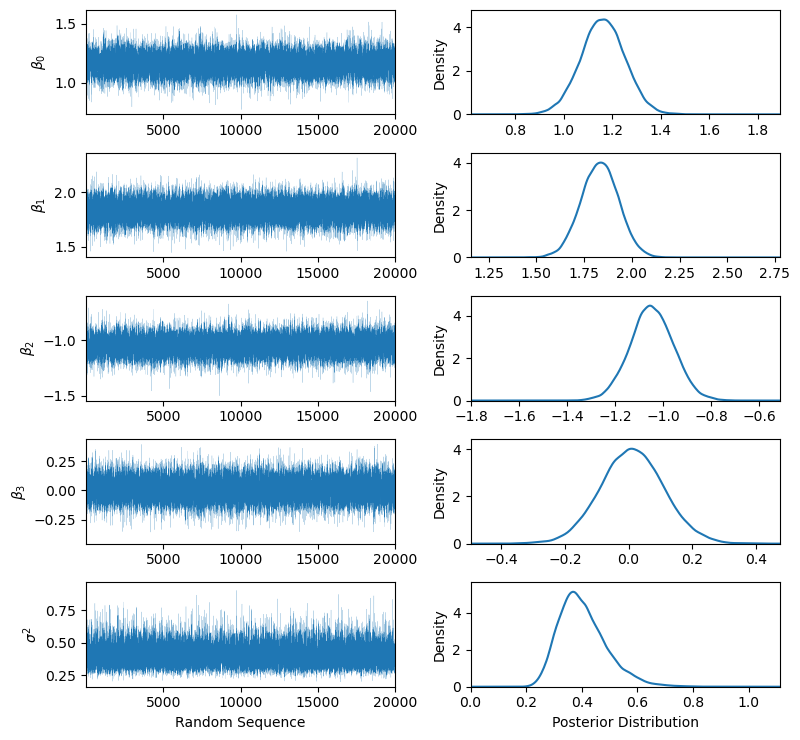

In [12]:
x_ridge, posterior_ridge = mcmc_plots(runs_ridge)

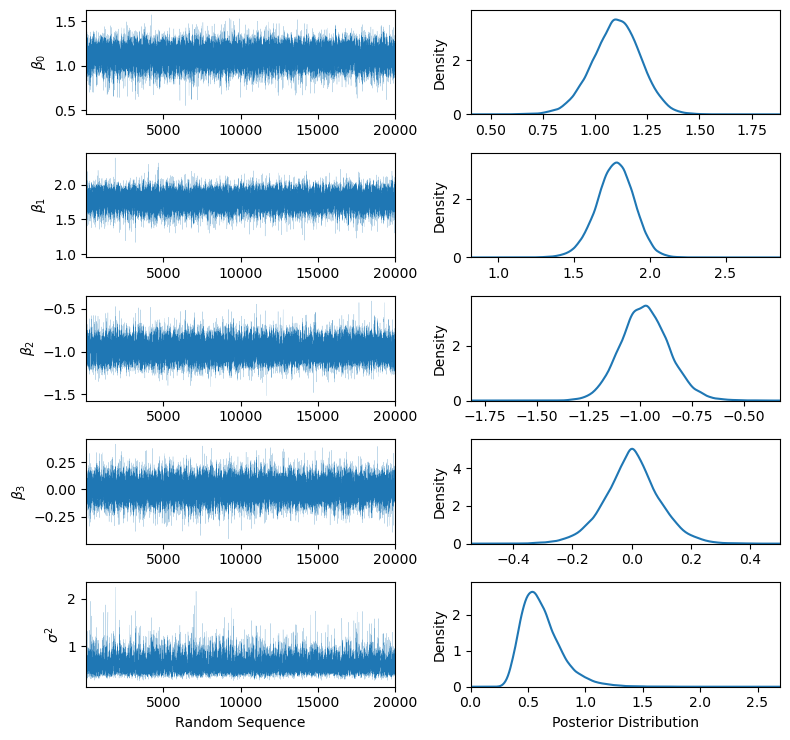

In [13]:
x_lasso, posterior_lasso = mcmc_plots(runs_lasso)

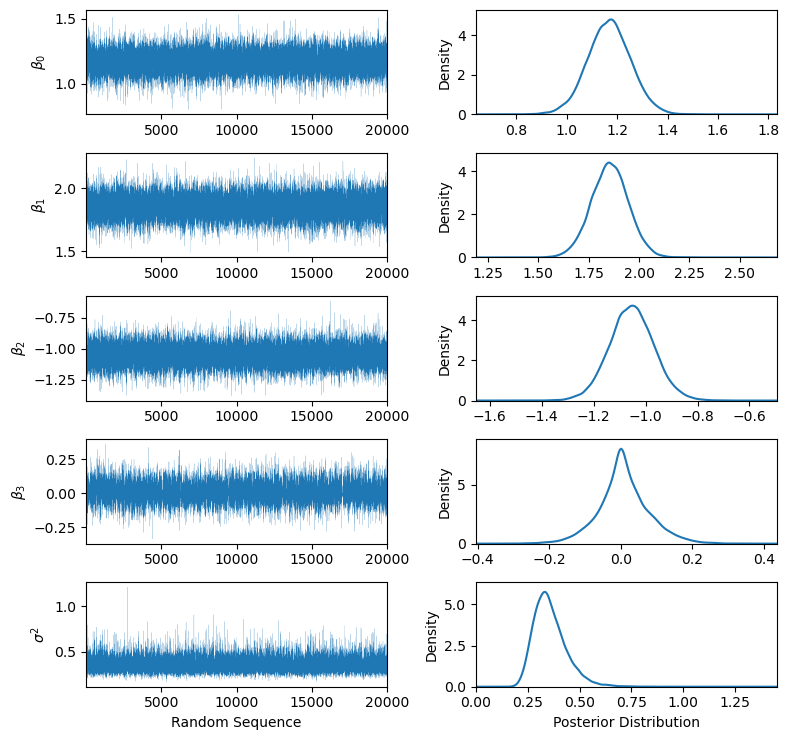

In [14]:
x_horseshoe, posterior_horseshoe = mcmc_plots(runs_horseshoe)

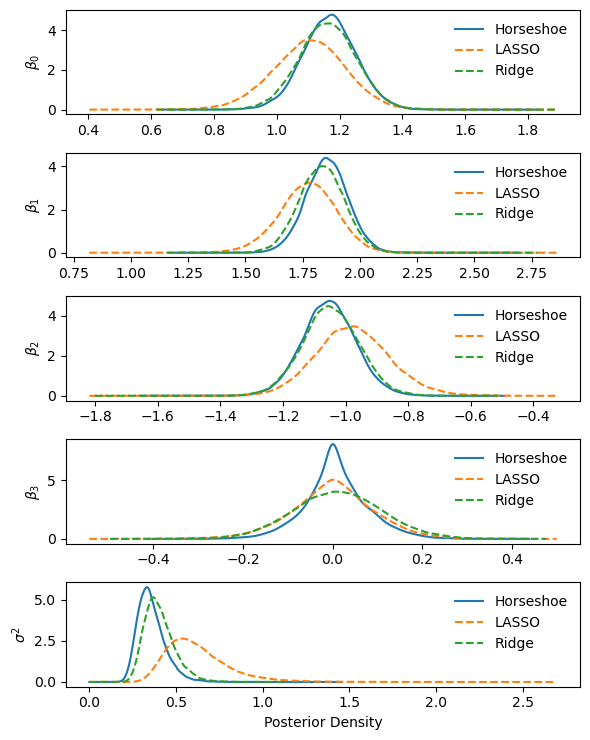

In [15]:
fig, ax = plt.subplots(k+1, 1, figsize=(6, 1.5*(k+1)), facecolor='w')
for index in range(k+1):
    if index < k:
        y_label = f'$\\beta_{index}$'
    else:
        y_label = '$\\sigma^2$'
        ax[index].set_xlabel('Posterior Density')
    ax[index].plot(x_horseshoe[:, index], posterior_horseshoe[:, index], '-', label='Horseshoe')
    ax[index].plot(x_lasso[:, index], posterior_lasso[:, index], '--', label='LASSO')
    ax[index].plot(x_ridge[:, index], posterior_ridge[:, index], '--', label='Ridge')
    ax[index].set_ylabel(y_label)
    ax[index].legend(loc='best', frameon=False)
plt.tight_layout()
plt.show()